# 03 -- Detectors, stack, and calibration

Six heterogeneous detectors -> rank-quantile features -> L2 logistic stacker -> isotonic calibration on a stratified sub-fold. Per-fold AUC and PR-AUC over the 12 walk-forward folds, plus reliability diagram on the calibrated probability.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sentinel_alpha.data.loader import load_dataset
from sentinel_alpha.data.transforms import stationarize
from sentinel_alpha.features.engineer import add_engineered
from sentinel_alpha.cv.walkforward import PurgedExpandingSplit
from sentinel_alpha.stack import StackPipeline
from sentinel_alpha.stack.calibrate import expected_calibration_error
sns.set_theme(style='whitegrid')

In [2]:
d = load_dataset(); Z = stationarize(d.X, d.type_map); F, _ = add_engineered(Z)
y = d.y.reindex(F.index).astype(int)
splitter = PurgedExpandingSplit(); folds = splitter.folds(F.index)

## Per-fold AUC and PR-AUC

For each fold we also record the per-detector AUC to expose the heterogeneity that motivates stacking.

In [3]:
rows = []; per_det_scores = []
for f in folds:
    Xtr, ytr = F.values[f.train_idx], y.values[f.train_idx]
    Xva, yva = F.values[f.val_idx],   y.values[f.val_idx]
    if ytr.sum() < 5 or yva.sum() in (0, len(yva)): continue
    pipe = StackPipeline().fit(Xtr, ytr)
    p_raw = pipe.predict_proba_raw(Xva); p_cal = pipe.predict_proba(Xva)
    Q = pipe.predict_detector_quantiles_df(Xva, f.val_dates)
    row = {'fold': f.fold_id, 'pos': int(yva.sum()),
           'AUC_stack': roc_auc_score(yva, p_raw),
           'PR_stack':  average_precision_score(yva, p_raw),
           'Brier_cal': brier_score_loss(yva, p_cal),
           'ECE_cal':   expected_calibration_error(yva, p_cal)}
    for name in pipe.detector_names:
        row[f'AUC_{name}'] = roc_auc_score(yva, Q[name])
    rows.append(row); per_det_scores.append((f.fold_id, Q.assign(y=yva)))
res = pd.DataFrame(rows).set_index('fold'); res

,pos,AUC_stack,PR_stack,Brier_cal,ECE_cal,AUC_mvg,AUC_gmm,AUC_iforest,AUC_kpca,AUC_copod,AUC_ae
fold,,,,,,,,,,,
1,2,0.900000,0.226190,0.037020,0.051523,0.865000,0.780000,0.455000,0.735000,0.470000,0.810000
2,10,0.471429,0.184354,0.348415,0.367277,0.498810,0.414286,0.526190,0.513095,0.585714,0.585714
3,40,0.781250,0.895904,0.177722,0.254759,0.834375,0.798958,0.809375,0.815625,0.807292,0.795833
4,12,0.764583,0.594711,0.188712,0.263645,0.798958,0.803125,0.832292,0.877083,0.890625,0.887500
5,13,0.731755,0.623377,0.288432,0.345439,0.766272,0.736686,0.707101,0.759369,0.685404,0.781065
6,33,0.724083,0.842557,0.238393,0.139110,0.723285,0.719298,0.637959,0.739234,0.678628,0.732057
8,2,0.550000,0.072482,0.111346,0.201609,0.470000,0.540000,0.620000,0.570000,0.620000,0.490000
9,10,0.497619,0.335000,0.165078,0.140719,0.470238,0.463095,0.478571,0.495238,0.509524,0.453571


In [4]:
print('Mean AUC stack:', res['AUC_stack'].mean().round(3))
auc_cols = [c for c in res.columns if c.startswith('AUC_') and c != 'AUC_stack']
(res[auc_cols].mean().sort_values(ascending=False)).rename('mean OOF AUC per detector')

Mean AUC stack: 0.678


AUC_ae         0.691968
AUC_kpca       0.688081
AUC_mvg        0.678367
AUC_gmm        0.656931
AUC_copod      0.655898
AUC_iforest    0.633311
Name: mean OOF AUC per detector, dtype: float64

## Stack vs single best detector

The point of the stack is not that each detector is great alone, but that they are *complementary*. Comparing the stacked AUC to the best single detector per fold tells us how much marginal lift the meta-learner is buying.

In [5]:
best_single = res[auc_cols].max(axis=1)
lift = res['AUC_stack'] - best_single
pd.DataFrame({'best_single': best_single, 'stack': res['AUC_stack'], 'lift': lift})

,best_single,stack,lift
fold,,,
1,0.865000,0.900000,0.035000
2,0.585714,0.471429,-0.114286
3,0.834375,0.781250,-0.053125
4,0.890625,0.764583,-0.126042
5,0.781065,0.731755,-0.049310
6,0.739234,0.724083,-0.015152
8,0.620000,0.550000,-0.070000
9,0.509524,0.497619,-0.011905


## Reliability diagram on pooled OOF data

We pool the calibrated probability across all CV folds and check that empirical frequency tracks predicted probability.

In [6]:
cv = pd.read_parquet('../artifacts/cv_probabilities.parquet')
y_pool = y.reindex(cv.index)
bins = np.linspace(0, 1, 11)
cv = cv.assign(bucket=np.clip(np.digitize(cv['p_cal'], bins)-1, 0, 9))
rel = cv.groupby('bucket').apply(lambda g: pd.Series({'pred': g['p_cal'].mean(),
    'empirical': y_pool.reindex(g.index).mean(), 'n': len(g)}), include_groups=False)
rel

,pred,empirical,n
bucket,,,
0,0.033649,0.080214,187.0
1,0.153321,0.029197,137.0
2,0.233891,0.166667,48.0
3,0.348201,0.100000,30.0
4,0.427303,0.135593,59.0
5,0.544849,0.345455,55.0
6,0.663238,0.655172,58.0
7,0.797020,0.000000,2.0
8,0.837536,0.428571,7.0


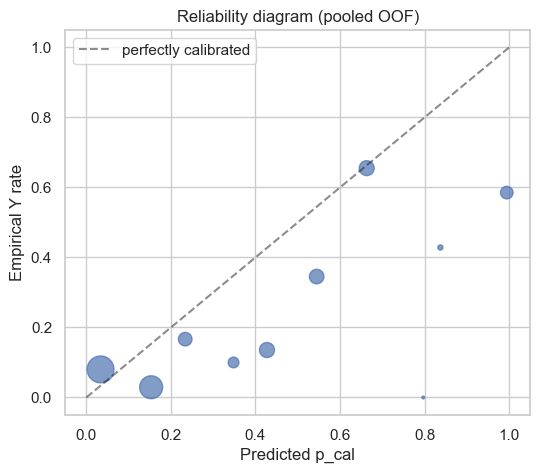

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0,1],[0,1],'k--', alpha=0.5, label='perfectly calibrated')
ax.scatter(rel['pred'], rel['empirical'], s=rel['n']*2, alpha=0.7)
ax.set_xlabel('Predicted p_cal'); ax.set_ylabel('Empirical Y rate')
ax.set_title('Reliability diagram (pooled OOF)')
ax.legend(); plt.show()